# GoogLeNet (Inception v1) for Diabetic Foot Ulcer (DFU) Image Classification
This notebook trains a **GoogLeNet (Inception v1)** model using transfer learning on DFU images with **5-Fold Cross-Validation**.  
Designed to run on **Kaggle GPU** environment.  
Uses the **preprocessing & training configuration** :
- **Optimizer**: Adam (lr = 1e-3)
- **Scheduler**: ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7)
- **EarlyStopping**: patience = 7
- **Class weights**: balanced (sklearn)
- **Augmentation**: H-flip, V-flip, Rotation ±20°, Zoom ±20%, Brightness ±10%, Contrast ±10%

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# KAGGLE SETUP — Clone repo & install dependencies
# Run this cell FIRST on Kaggle to pull the project code and utilities.
# ══════════════════════════════════════════════════════════════════════════════
import os

REPO_URL    = 'https://github.com/csstudentkaum/KHOTAA.git'
BRANCH      = 'new-start'
REPO_DIR    = '/kaggle/working/KHOTAA'
WORKING_DIR = os.path.join(REPO_DIR, 'models', 'classification')

# Clone the repo (skip if already cloned)
if not os.path.exists(REPO_DIR):
    !git clone --branch {BRANCH} --single-branch {REPO_URL} {REPO_DIR}
    print(f"✓ Cloned {BRANCH} branch → {REPO_DIR}")
else:
    print(f"✓ Repo already exists at {REPO_DIR}")

# Change into the notebook's expected working directory
os.chdir(WORKING_DIR)
print(f"✓ Working directory: {os.getcwd()}")

# Install additional dependencies
!pip install roboflow -q
print("✓ Kaggle setup complete")

Cloning into '/kaggle/working/KHOTAA'...
remote: Enumerating objects: 583, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 583 (delta 32), reused 36 (delta 25), pack-reused 535 (from 1)
Receiving objects: 100% (583/583), 20.83 MiB | 30.38 MiB/s, done.
Resolving deltas: 100% (277/277), done.
✓ Cloned new-start branch → /kaggle/working/KHOTAA
✓ Working directory: /kaggle/working/KHOTAA/models/classification
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 37.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 96.6 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behavi

## 1. Imports & Configuration

In [2]:
# ── Standard Library ──────────────────────────────────────────────────────────
import sys
import os
import random
import warnings
import json
warnings.filterwarnings('ignore')

# ── Numerical & Visualization ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import googlenet, GoogLeNet_Weights
from PIL import Image

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from datetime import datetime
import copy

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Project imports ───────────────────────────────────────────────────────────
# Works both locally (../utils) and on Kaggle (cloned repo structure)
sys.path.append('../')
sys.path.append('./')

import importlib
from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing
from utils import training_engine
importlib.reload(training_engine)
from utils.training_engine import (
    TrainingEngine, create_optimizer, create_scheduler,
    compute_balanced_class_weights
)
from utils.metrics_evaluator import (
    calculate_metrics, print_metrics,
    plot_confusion_matrix, plot_roc_curve, plot_training_history
)

# ── Hyperparameters & Paths (aligned with DenseNet121 notebook) ───────────────
IMAGE_SIZE       = (224, 224)
BATCH_SIZE       = 32
EPOCHS           = 30
LEARNING_RATE    = 1e-3
FINE_TUNE_LR     = 1e-5
N_FOLDS          = 5

# ── Roboflow Dataset ──────────────────────────────────────────────────────────
from roboflow import Roboflow
rf = Roboflow(api_key="aOyWN2odFMV7P4HudwVJ")
project = rf.workspace("dfu-o28ut").project("dfu-kew1f-gzodp")
version = project.version(1)
dataset = version.download("folder")
DATASET_PATH = dataset.location + "/"

# ── Directories ───────────────────────────────────────────────────────────────
MODEL_NAME       = 'GoogLeNet'
RESULTS_DIR      = 'results'

print("✓ Imports complete (modules reloaded)")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"Image size      : {IMAGE_SIZE}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Dataset path    : {DATASET_PATH}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DFU-1 in folder:: 100%|██████████| 4462/4462 [00:00<00:00, 11943.29it/s]

✓ Imports complete (modules reloaded)
PyTorch version : 2.9.0+cu126
CUDA available  : True
Image size      : (224, 224)
Batch size      : 32
Dataset path    : /kaggle/working/KHOTAA/models/classification/DFU-1/


## 2. Load & Explore Dataset

In [3]:
# ── Verify dataset directory structure ────────────────────────────────────────
print('Dataset root contents:')
for entry in sorted(os.listdir(DATASET_PATH)):
    full = os.path.join(DATASET_PATH, entry)
    kind = 'DIR' if os.path.isdir(full) else 'FILE'
    print(f'  [{kind}] {entry}')

# ── Load dataset (auto-detects train/valid/val/test splits) ──────────────────
loader = SplitFolderDatasetLoader(root_dir=DATASET_PATH)
classes = loader.get_classes()
num_classes = loader.get_num_classes()

print(f"\nClasses: {classes}")
print(f"Number of classes: {num_classes}")

# ── Print full structure overview ─────────────────────────────────────────────
loader.print_structure()

# ── Initialize preprocessing ─────────────────────────────────────────────────
preprocessor = DFUPreprocessing()
train_transform    = preprocessor.get_train_transforms()
val_test_transform = preprocessor.get_valid_test_transforms()

# ── PyTorch Dataset class ─────────────────────────────────────────────────────
class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# ── Prepare data for cross-validation (train + valid combined) ────────────────
X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val     = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

# ── Initialize 5-fold stratified cross-validation ────────────────────────────
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f"\nTotal training samples (train+valid): {len(X_all)}")
print("✓ Dataset loaded and ready for 5-fold cross-validation")

Dataset root contents:
  [FILE] README.roboflow.txt
  [DIR] test
  [DIR] train
  [DIR] valid
[DatasetLoader] Root: /kaggle/working/KHOTAA/models/classification/DFU-1
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Both', 'Infection', 'Ischaemia', 'None']

Classes: ['Both', 'Infection', 'Ischaemia', 'None']
Number of classes: 4

Dataset root: /kaggle/working/KHOTAA/models/classification/DFU-1
  [FILE] README.roboflow.txt
  [DIR] test
  [DIR] train
  [DIR] valid

[DatasetLoader] Split 'train': 3112 images
  Split 'train' (3112 images):
    Both: 323  (10.4%)
    Infection: 1327  (42.6%)
    Ischaemia: 111  (3.6%)
    None: 1351  (43.4%)
[DatasetLoader] Split 'valid': 889 images
  Split 'valid' (889 images):
    Both: 93  (10.5%)
    Infection: 381  (42.9%)
    Ischaemia: 41  (4.6%)
    None: 374  (42.1%)
[DatasetLoader] Split 'test': 445 images
  Split 'test' (445 images):
    Both: 45  (10.1%)
    Infection: 193  (43.4%)
    Ischaemia: 15  (3.4%)
    No

[DatasetLoader] Split 'train': 3112 images


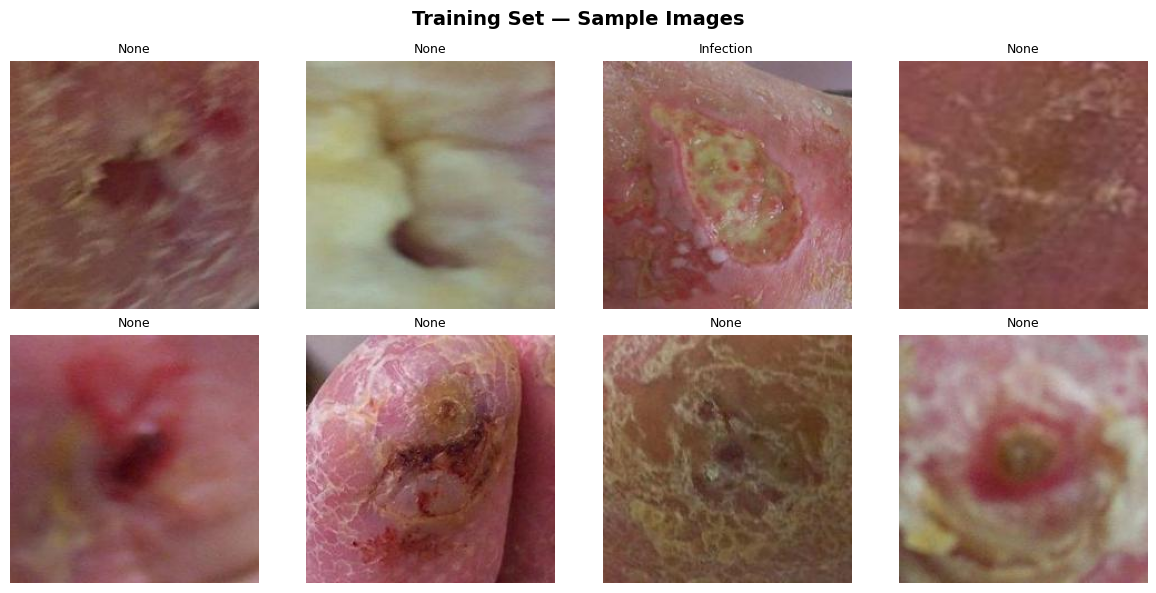

In [4]:
# ── Display sample images from training set ───────────────────────────────────
loader.show_samples('train', n_cols=4, n_rows=2, title='Training Set — Sample Images')

[DatasetLoader] Split 'train': 3112 images
[DatasetLoader] Split 'valid': 889 images
[DatasetLoader] Split 'test': 445 images


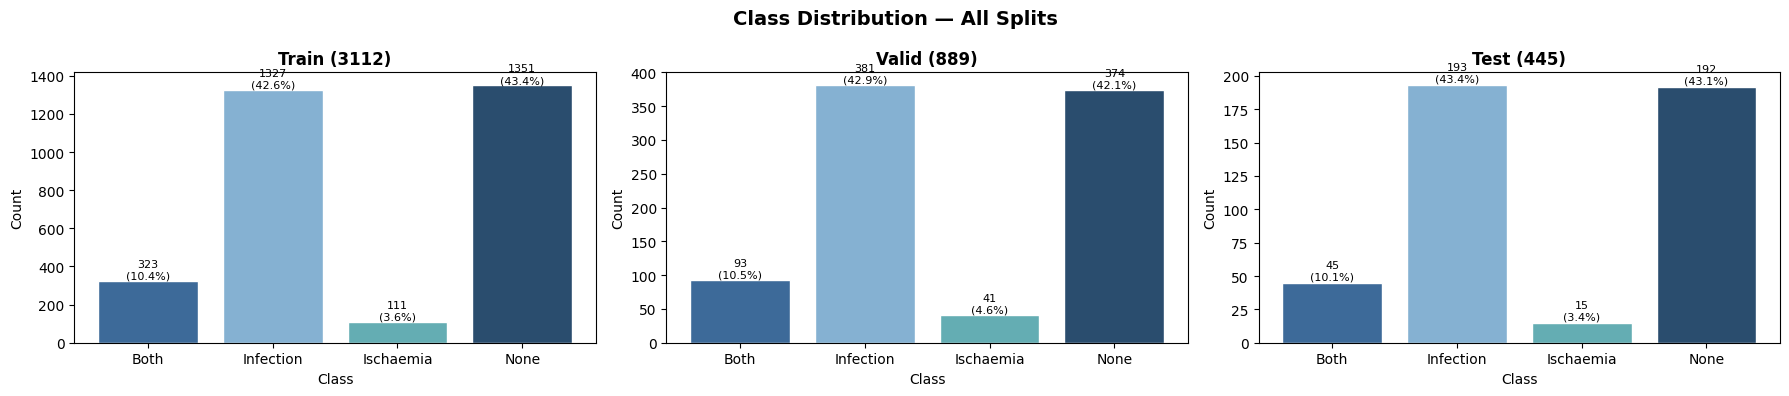

Total training+val samples: 4001
Class counts: {'Both': 416, 'Infection': 1708, 'Ischaemia': 152, 'None': 1725}


In [5]:
import matplotlib.pyplot as plt

PALETTE = ["#3D6A99", "#85B1D2", "#64ADB3", "#2A4D6E"]

# Override plt.show to intercept the figure before it's displayed
original_show = plt.show

def custom_show():
    fig = plt.gcf()
    for ax in fig.axes:
        for i, bar in enumerate(ax.patches):
            bar.set_facecolor(PALETTE[i % len(PALETTE)])
            bar.set_edgecolor('white')
    original_show()

plt.show = custom_show

# Now call — the colors will be applied before display
loader.plot_all_splits_distribution()

# Restore
plt.show = original_show

print(f"Total training+val samples: {len(y_all)}")
print(f"Class counts: { {classes[i]: int(np.sum(y_all == i)) for i in range(num_classes)} }")

## 3. Data Preprocessing & Augmentation Visualization

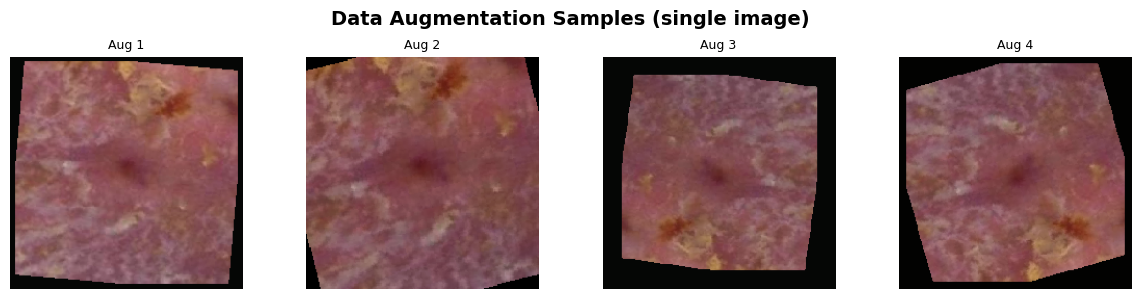

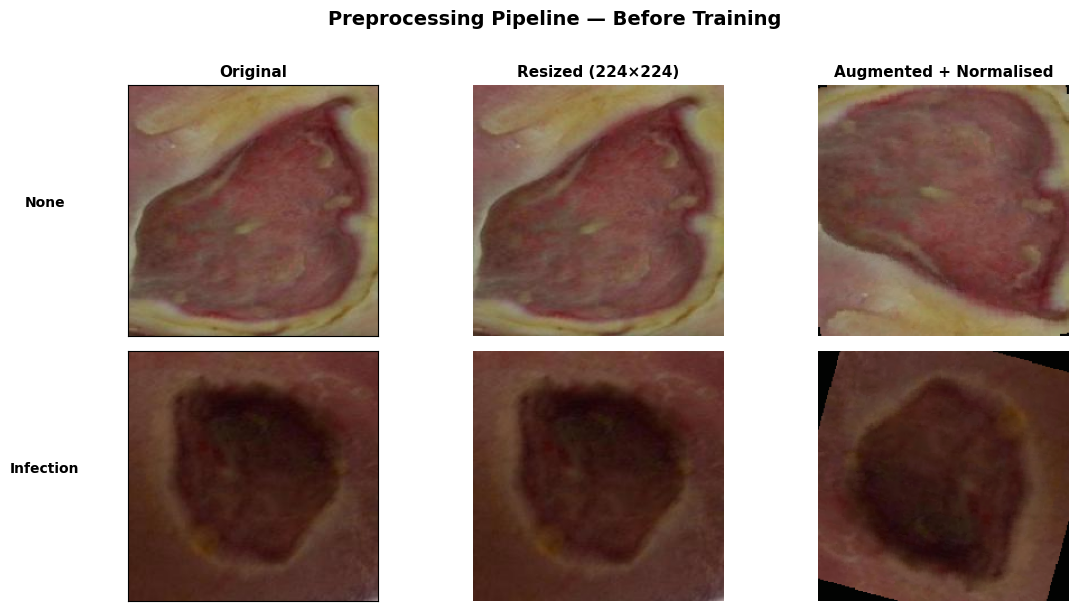

Note: PyTorch applies augmentation on-the-fly during training,
so class counts remain the same. Augmentation adds visual variety, not extra samples.


In [6]:
# ── Visualise augmentation on a single image ──────────────────────────────────
sample_path = X_train[0]
preprocessor.show_augmentation_samples(
    sample_path, n_samples=4,
    title='Data Augmentation Samples (single image)'
)

# ── Preprocessing sample results: Original → Resized → Augmented+Normalised ──
preprocessor.show_preprocessing_samples(
    X_train, y_train, classes,
    n_samples=2,
    title='Preprocessing Pipeline — Before Training'
)

print("Note: PyTorch applies augmentation on-the-fly during training,")
print("so class counts remain the same. Augmentation adds visual variety, not extra samples.")

## 4. Build Model (Transfer Learning)

In [7]:
# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Create GoogLeNet model ────────────────────────────────────────────────────
def create_googlenet_model(num_classes=4, pretrained=True):
    """
    Create GoogLeNet (Inception v1) model for DFU classification.
    Uses ImageNet pretrained weights with custom classification head.
    
    Architecture:
        GoogLeNet backbone (with auxiliary classifiers during training)
        → Dropout(0.2) → Linear(1024 → num_classes)
    
    GoogLeNet-specific handling:
        - During TRAINING: model returns (main_output, aux2, aux1)
        - During EVAL: model returns only main_output
        - Auxiliary losses weighted at 0.3x each (standard GoogLeNet practice)
    
    Args:
        num_classes: Number of output classes (default: 4)
        pretrained: Use ImageNet pretrained weights (default: True)
    
    Returns:
        model: GoogLeNet model ready for training
    """
    from torchvision.models import GoogLeNet_Weights
    
    # CRITICAL: Load pretrained GoogLeNet with auxiliary classifiers ENABLED
    if pretrained:
        weights = GoogLeNet_Weights.IMAGENET1K_V1
        model = models.googlenet(weights=weights, aux_logits=True)
        print("✓ Loaded GoogLeNet with ImageNet pretrained weights")
    else:
        model = models.googlenet(weights=None, aux_logits=True)
        print("✓ Initialized GoogLeNet with random weights")
    
    # Replace final fully connected layer
    # GoogLeNet FC: in_features = 1024
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    # CRITICAL: Modify auxiliary classifiers (active only during training)
    # aux1 and aux2 are InceptionAux modules with fc2 as final layer
    model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, num_classes)
    model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, num_classes)
    
    print(f"✓ Modified classification heads:")
    print(f"  Main FC: {in_features} → {num_classes}")
    print(f"  Aux1 FC: 512 → 128 → {num_classes}")
    print(f"  Aux2 FC: 528 → 128 → {num_classes}")
    print(f"  Note: Auxiliary classifiers only active during training (model.training=True)")
    
    return model

# ── Instantiate model ─────────────────────────────────────────────────────────
model = create_googlenet_model(num_classes=num_classes, pretrained=True)
model = model.to(device)

print(f"\n✓ Model loaded on {device}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Device: cuda
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 150MB/s] 


✓ Loaded GoogLeNet with ImageNet pretrained weights
✓ Modified classification heads:
  Main FC: 1024 → 4
  Aux1 FC: 512 → 128 → 4
  Aux2 FC: 528 → 128 → 4
  Note: Auxiliary classifiers only active during training (model.training=True)

✓ Model loaded on cuda
  Total parameters: 9,942,188
  Trainable parameters: 9,942,188


## 5. Class Weights

Compute balanced class weights to handle class imbalance.

In [8]:
# ── Compute balanced class weights  ─────────────
class_weights_tensor = compute_balanced_class_weights(y_all, device=device)

# ── Create weighted loss function ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
print(f"\n✓ CrossEntropyLoss with balanced class weights")
print(f"  Weights: {class_weights_tensor.cpu().numpy()}")
print(f"  Classes: {classes}")

[ClassWeights] Balanced class weights: {0: 2.4044471153846154, 1: 0.5856264637002342, 2: 6.5805921052631575, 3: 0.5798550724637681}

✓ CrossEntropyLoss with balanced class weights
  Weights: [2.404447  0.5856265 6.580592  0.5798551]
  Classes: ['Both', 'Infection', 'Ischaemia', 'None']


## 6. Training (5-Fold Cross-Validation)

Training configuration (aligned with DenseNet121 notebook):
- **Optimizer**: Adam (lr = 1e-3)
- **Scheduler**: ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7)
- **EarlyStopping**: patience = 7, monitors val_loss, restores best weights
- **Loss**: CrossEntropyLoss with balanced class weights
- **Epochs**: 30 max per fold

**⚠️ GoogLeNet-Specific Note:**
- GoogLeNet has auxiliary classifiers that are active during training
- Training loss = main_loss + 0.3 × aux2_loss + 0.3 × aux1_loss
- During validation/testing, only main output is used (eval mode)
- This is handled automatically by the custom training wrapper


In [9]:
# ── 5-Fold Cross-Validation Training ──────────────────────────────────────────
fold_results = []
best_model_state = None       # Best model weights across ALL folds (in memory)
best_overall_acc = 0.0
fold_model_states = {}        # Per-fold best model weights (for aggregated CM)

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_all, y_all), 1):
    print(f"\n{'='*60}\nFOLD {fold}/{N_FOLDS}\n{'='*60}")
    
    # Prepare fold data
    X_train_fold = X_all[train_idx]
    y_train_fold = y_all[train_idx]
    X_val_fold   = X_all[val_idx]
    y_val_fold   = y_all[val_idx]
    
    train_dataset = DFUDataset(X_train_fold, y_train_fold, transform=train_transform)
    val_dataset   = DFUDataset(X_val_fold, y_val_fold, transform=val_test_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Create fresh model for this fold
    model = create_googlenet_model(num_classes=num_classes, pretrained=True)
    model = model.to(device)
    
    # Setup optimizer: Adam with lr=1e-3 (matching DenseNet121 notebook)
    optimizer = create_optimizer(model, optimizer_type='adam', lr=LEARNING_RATE, weight_decay=1e-4)
    
    # Setup scheduler: ReduceLROnPlateau (matching DenseNet121 notebook)
    scheduler = create_scheduler(optimizer, scheduler_type='plateau',
                                 gamma=0.3, patience=3, min_lr=1e-7)
    
    # Training engine with GoogLeNet auxiliary classifier support
    engine = TrainingEngine(model=model, device=device)
    
    # Wrap train_epoch to handle GoogLeNet auxiliary outputs
    original_train_epoch = engine.train_epoch
    def train_epoch_googlenet(train_loader, criterion, optimizer):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            # GoogLeNet returns (main_out, aux2_out, aux1_out) when training=True
            outputs = model(inputs)
            if isinstance(outputs, tuple):
                main_out, aux2, aux1 = outputs
                main_loss = criterion(main_out, labels)
                aux2_loss = criterion(aux2, labels)
                aux1_loss = criterion(aux1, labels)
                # Standard GoogLeNet auxiliary weighting
                loss = main_loss + 0.3 * aux2_loss + 0.3 * aux1_loss
                outputs = main_out  # Use main output for accuracy
            else:
                loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        return epoch_loss, epoch_acc
    
    engine.train_epoch = train_epoch_googlenet
    
    # Track best model state for this fold IN the training loop
    fold_best_state = None
    fold_best_acc = 0.0
    
    # Custom training loop to capture best model state in memory
    from utils.training_engine import EarlyStopping
    early_stopper = EarlyStopping(patience=7, verbose=True)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'stopped_epoch': EPOCHS
    }
    
    for epoch in range(EPOCHS):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"{'='*60}")
        
        # Train
        train_loss, train_acc = engine.train_epoch(train_loader, criterion, optimizer)
        
        # Validate
        val_loss, val_acc, _, _, _ = engine.evaluate(val_loader, criterion, measure_inference_time=False)
        
        # Update learning rate
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Learning Rate: {current_lr:.6f}")
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Print epoch results
        print(f"\nEpoch {epoch+1} Results:")
        print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
        
        # Save best model state IN MEMORY
        if val_acc > fold_best_acc:
            fold_best_acc = val_acc
            fold_best_state = copy.deepcopy(model.state_dict())
            print(f"   ✓ New best model! Val Acc: {val_acc*100:.2f}%")
        
        # Check early stopping
        if early_stopper(val_loss, epoch+1):
            history['stopped_epoch'] = epoch + 1
            print(f"\n{'='*60}")
            print(f"Training stopped early at epoch {epoch+1}/{EPOCHS}")
            print(f"Best Validation Accuracy: {fold_best_acc*100:.2f}%")
            print(f"{'='*60}\n")
            break
    else:
        history['stopped_epoch'] = EPOCHS
        print(f"\n{'='*60}")
        print(f"Training Complete! All {EPOCHS} epochs")
        print(f"Best Validation Accuracy: {fold_best_acc*100:.2f}%")
        print(f"{'='*60}\n")
    
    # Store best model state for this fold
    fold_model_states[fold] = fold_best_state
    
    # Track overall best model across all folds
    if fold_best_acc > best_overall_acc:
        best_overall_acc = fold_best_acc
        best_model_state = copy.deepcopy(fold_best_state)
    
    # Store results
    best_val_acc = fold_best_acc
    fold_results.append({
        'fold': fold,
        'best_val_acc': best_val_acc,
        'final_val_acc': history['val_acc'][-1],
        'stopped_epoch': history['stopped_epoch'],
        'history': history
    })
    print(f"Fold {fold} — Best Acc: {best_val_acc*100:.2f}% (stopped at epoch {history['stopped_epoch']})")

# ── Cross-validation summary ─────────────────────────────────────────────────
avg_acc    = np.mean([r['best_val_acc'] for r in fold_results])
std_acc    = np.std([r['best_val_acc'] for r in fold_results])
avg_epochs = np.mean([r['stopped_epoch'] for r in fold_results])

print(f"\n{'='*60}")
print(f"5-FOLD CROSS-VALIDATION RESULTS")
print(f"{'='*60}")
print(f"Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"Average Epochs: {avg_epochs:.1f}")
print(f"\nIndividual Fold Results:")
for r in fold_results:
    print(f"  Fold {r['fold']}: {r['best_val_acc']*100:.2f}% (epoch {r['stopped_epoch']})")
print(f"{'='*60}")


FOLD 1/5
✓ Loaded GoogLeNet with ImageNet pretrained weights
✓ Modified classification heads:
  Main FC: 1024 → 4
  Aux1 FC: 512 → 128 → 4
  Aux2 FC: 528 → 128 → 4
  Note: Auxiliary classifiers only active during training (model.training=True)
Created Adam optimizer: lr=0.001, weight_decay=0.0001
Created ReduceLROnPlateau scheduler: mode=min, patience=3, factor=0.3, min_lr=1e-07
Training on: cuda

Epoch 1/30


Evaluating: 100%|██████████| 26/26 [00:01<00:00, 13.48it/s, loss=0.7582, acc=63.55%]


Learning Rate: 0.001000

Epoch 1 Results:
   Train Loss: 1.7603 | Train Acc: 55.56%
   Val Loss:   1.0563 | Val Acc:   63.55%
   ✓ New best model! Val Acc: 63.55%

Epoch 2/30


Evaluating: 100%|██████████| 26/26 [00:01<00:00, 14.52it/s, loss=0.6972, acc=47.07%]


Learning Rate: 0.001000

Epoch 2 Results:
   Train Loss: 1.4354 | Train Acc: 63.00%
   Val Loss:   1.1746 | Val Acc:   47.07%

Epoch 3/30


...

Learning Rate: 0.000300

Epoch 28 Results:
   Train Loss: 0.6758 | Train Acc: 78.41%
   Val Loss:   0.5187 | Val Acc:   75.25%

Epoch 29/30


Evaluating: 100%|██████████| 25/25 [00:01<00:00, 13.90it/s, loss=0.5683, acc=78.88%]


Learning Rate: 0.000300

Epoch 29 Results:
   Train Loss: 0.5969 | Train Acc: 80.10%
   Val Loss:   0.5745 | Val Acc:   78.88%
   ✓ New best model! Val Acc: 78.88%

Epoch 30/30


Evaluating: 100%|██████████| 25/25 [00:01<00:00, 14.12it/s, loss=0.5540, acc=78.00%]

Learning Rate: 0.000300

Epoch 30 Results:
   Train Loss: 0.6073 | Train Acc: 79.38%
   Val Loss:   0.4670 | Val Acc:   78.00%

Training Complete! All 30 epochs
Best Validation Accuracy: 78.88%

Fold 5 — Best Acc: 78.88% (stopped at epoch 30)

5-FOLD CROSS-VALIDATION RESULTS
Mean Accuracy: 78.96% ± 0.98%
Average Epochs: 30.0

Individual Fold Results:
  Fold 1: 77.15% (epoch 30)
  Fold 2: 79.12% (epoch 30)
  Fold 3: 79.75% (epoch 30)
  Fold 4: 79.88% (epoch 30)
  Fold 5: 78.88% (epoch 30)


## 7. Training Curves & Evaluation Plots

✓ Results directory: /kaggle/working/KHOTAA/models/classification/results/googlenet
✓ Best fold: 4 (79.88%)
✓ Loaded best model from MEMORY


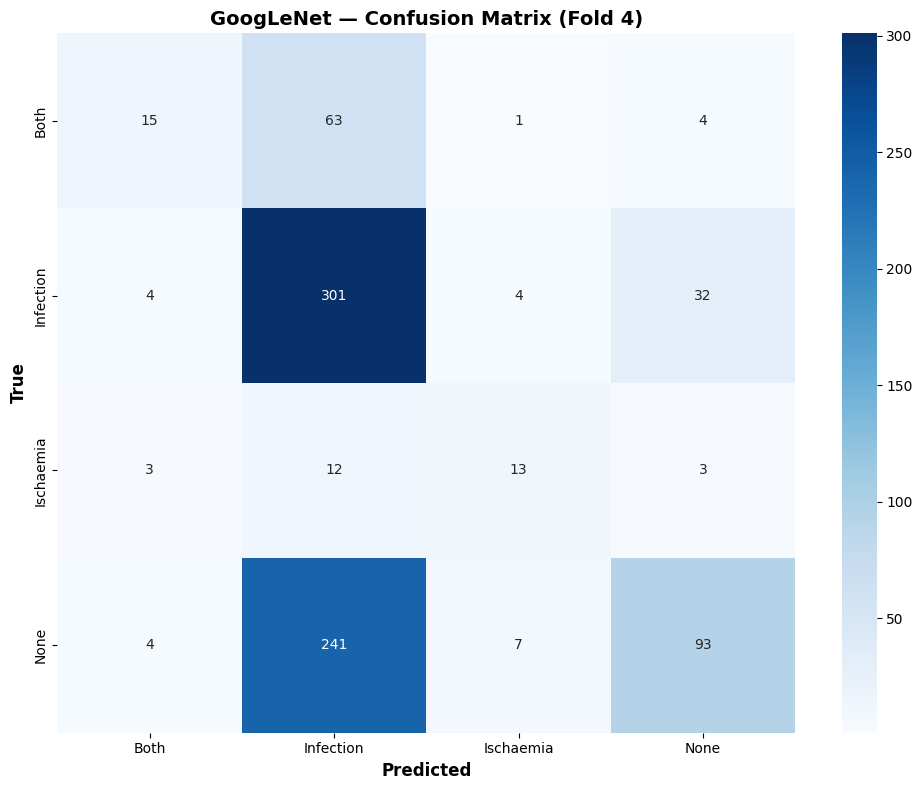


⏳ Generating aggregated confusion matrix across all folds...
  ✓ Fold 1 processed
  ✓ Fold 2 processed
  ✓ Fold 3 processed
  ✓ Fold 4 processed
  ✓ Fold 5 processed


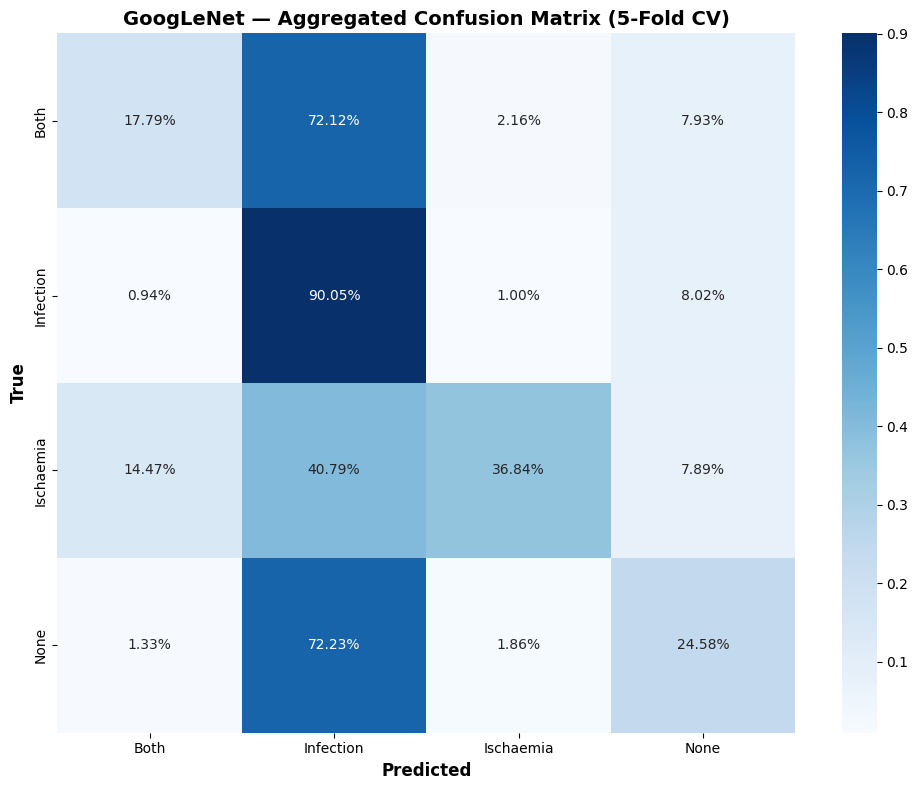

✓ Aggregated CM saved (4001 total predictions)


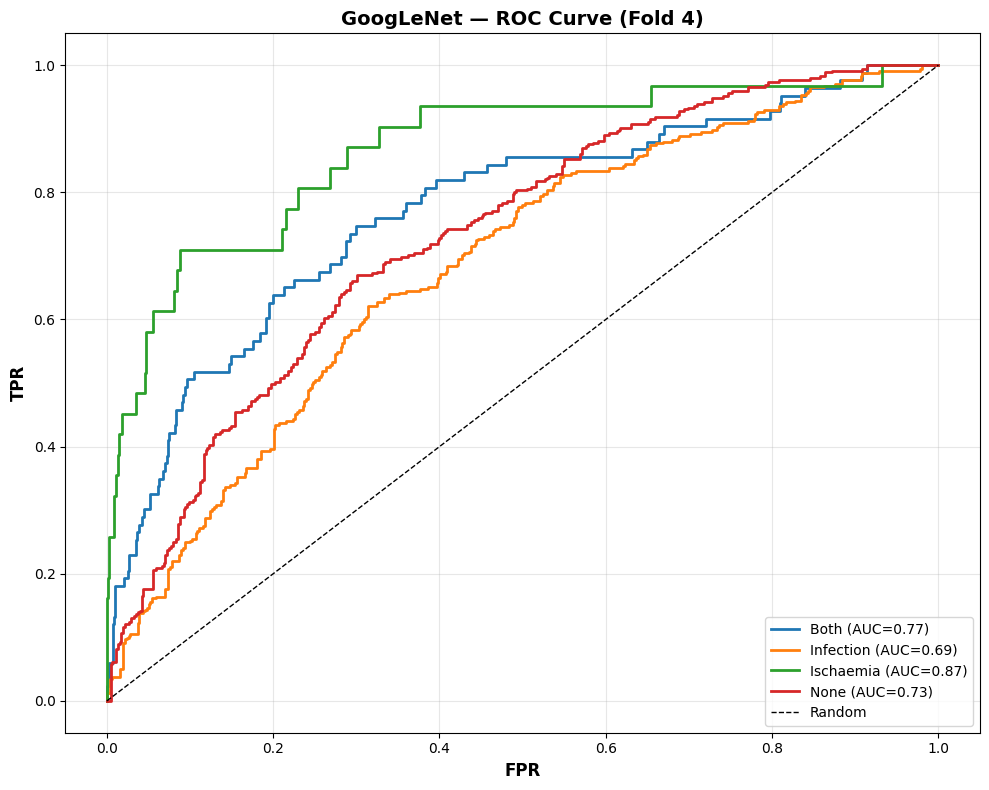

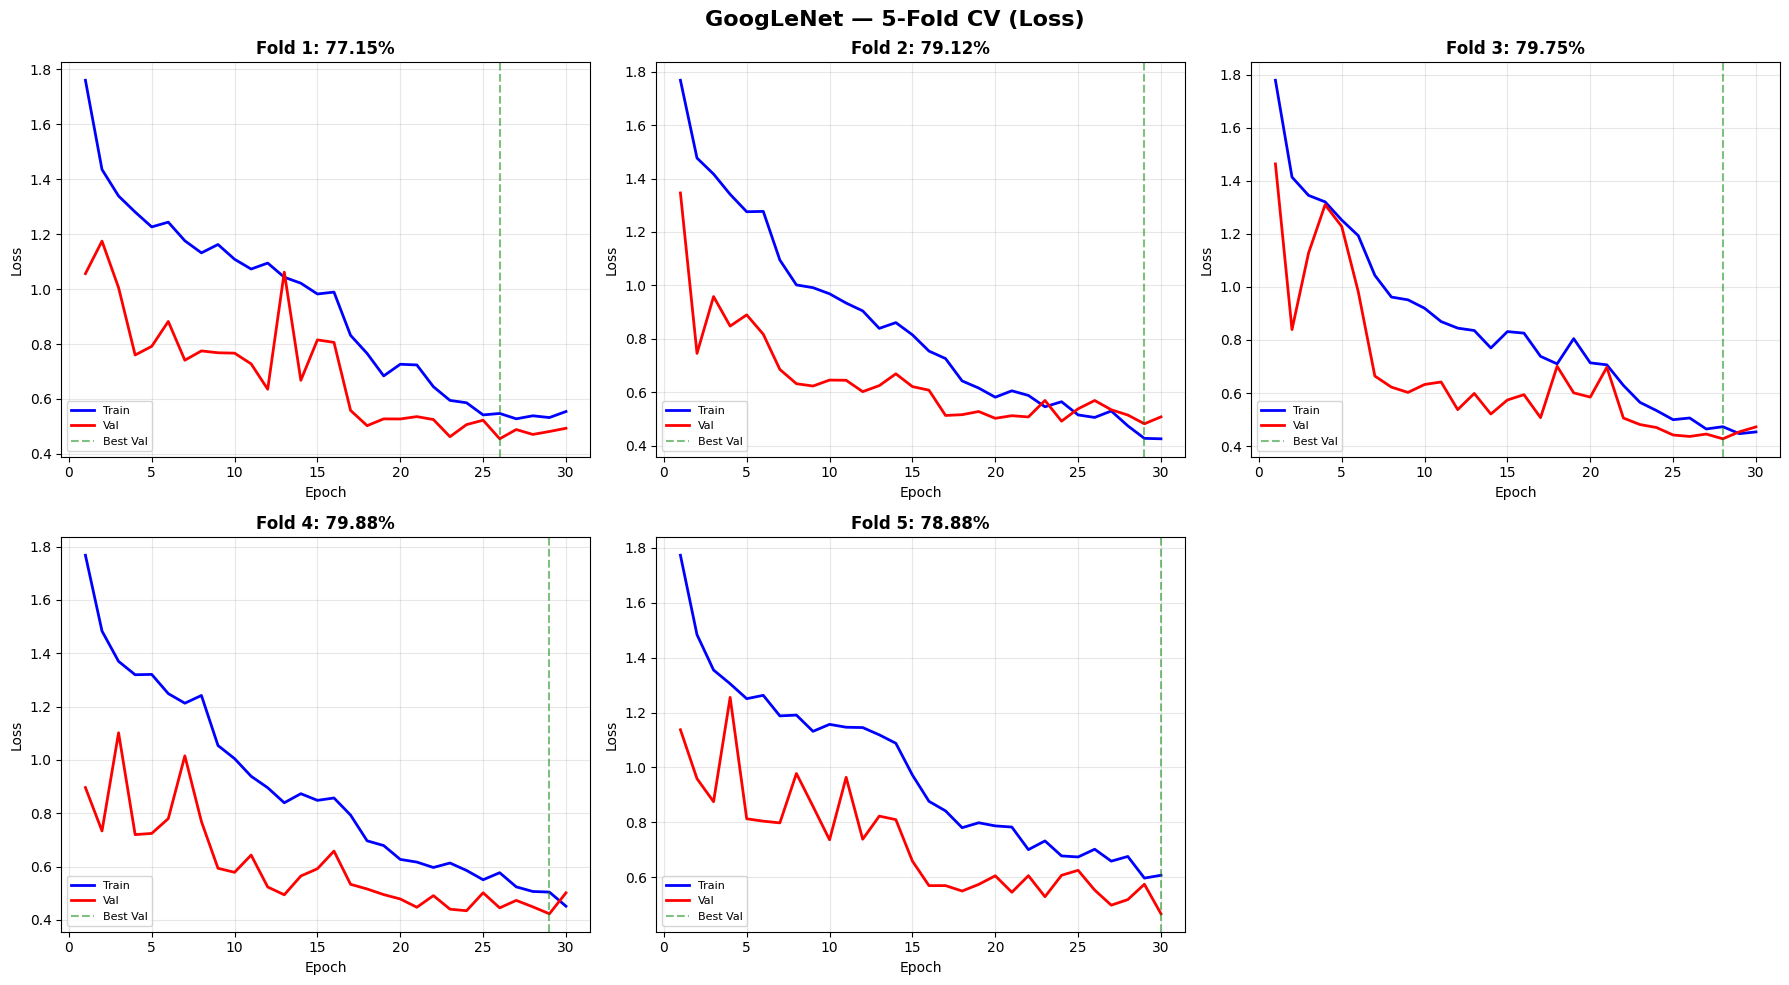

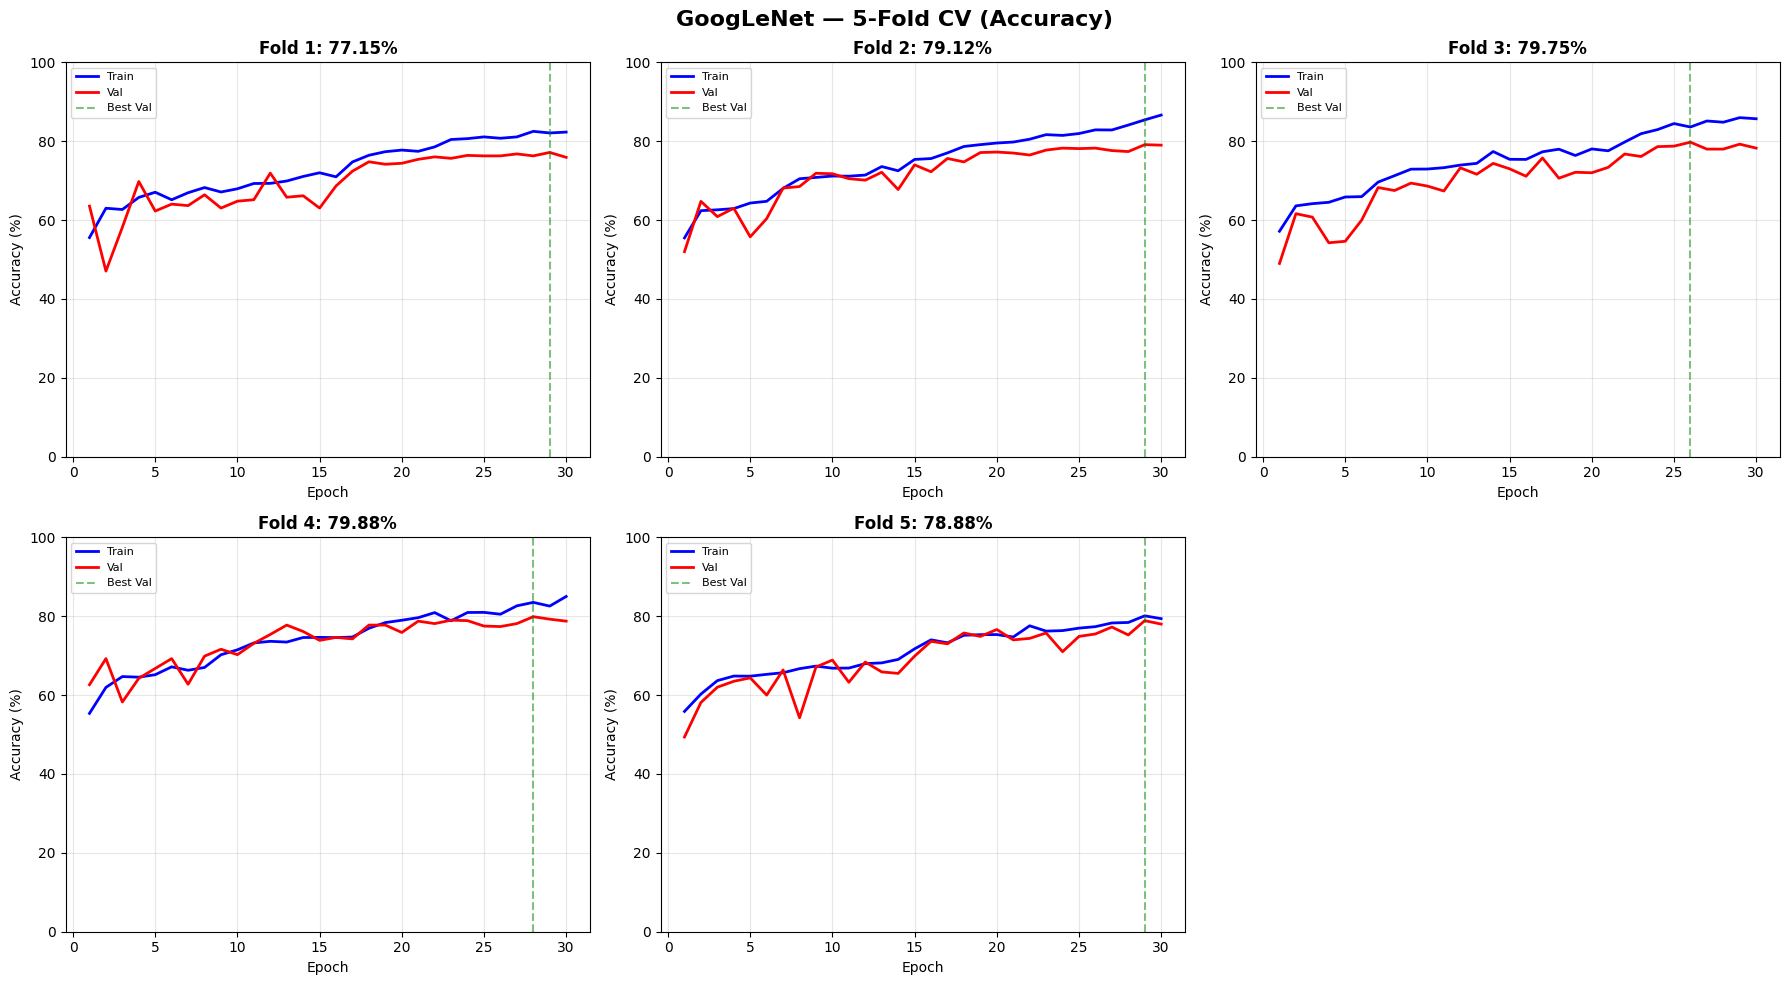

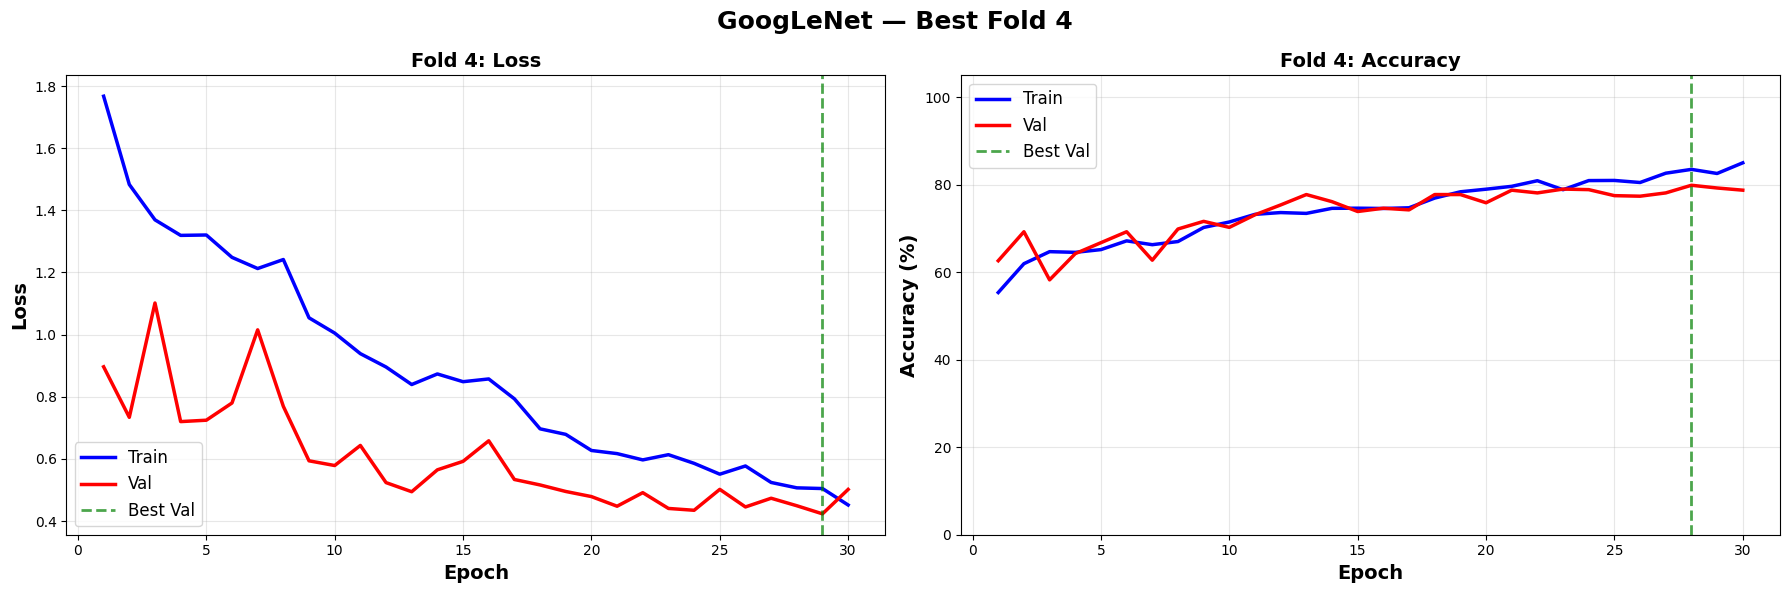


GoogLeNet CROSS-VALIDATION SUMMARY
Mean Accuracy: 78.96% ± 0.98%
Best Fold: 4 (79.88%)
Model loaded from: MEMORY
Average Epochs: 30.0
Results saved → results/googlenet/googlenet_cv_results.json


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
DPI = 300
PLOT_CONFIG = {
    'cm':      {'size': (10, 8), 'cmap': 'Blues'},
    'roc':     {'size': (10, 8), 'lw': 2},
    'history': {'size': (18, 10)},
}
FONT = {'title': 14, 'label': 12, 'legend': 10, 'tick': 10}

# Create model-specific results directory
model_results_dir = os.path.join(RESULTS_DIR, MODEL_NAME.lower())
os.makedirs(model_results_dir, exist_ok=True)
print(f"✓ Results directory: {os.path.abspath(model_results_dir)}")

# ══════════════════════════════════════════════════════════════════════════════
# GET BEST FOLD & LOAD BEST MODEL (from memory)
# ══════════════════════════════════════════════════════════════════════════════
best_fold_idx = int(np.argmax([r['best_val_acc'] for r in fold_results]))
best_fold_num = fold_results[best_fold_idx]['fold']

# ── CREATE GOOLENET WITH CORRECT NUM_CLASSES ───────────────────────────────────
from torchvision.models import googlenet, GoogLeNet_Weights
import torch.nn as nn

def create_googlenet_model(num_classes=4, pretrained=False):
    model = googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1 if pretrained else None, aux_logits=True)
    # تعديل الطبقات الأخيرة لتتناسب مع عدد الكلاسات
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, num_classes)
    model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, num_classes)
    return model

model = create_googlenet_model(num_classes=num_classes, pretrained=False)
model.load_state_dict(best_model_state)
model = model.to(device).eval()
print(f"✓ Best fold: {best_fold_num} ({fold_results[best_fold_idx]['best_val_acc']*100:.2f}%)")
print(f"✓ Loaded best model from MEMORY")

# ══════════════════════════════════════════════════════════════════════════════
# GET PREDICTIONS (BEST FOLD)
# ══════════════════════════════════════════════════════════════════════════════
fold_splits = list(kfold.split(X_all, y_all))
train_idx, val_idx = fold_splits[best_fold_idx]
val_dataset = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

predictions  = np.concatenate(all_preds)
true_labels  = np.concatenate(all_labels)
y_pred_proba = np.vstack(all_probs)

# ══════════════════════════════════════════════════════════════════════════════
# 1. CONFUSION MATRIX (BEST FOLD — RAW COUNTS)
# ══════════════════════════════════════════════════════════════════════════════
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
sns.heatmap(cm, annot=True, fmt='d', cmap=PLOT_CONFIG['cm']['cmap'],
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (Fold {best_fold_num})',
             fontsize=FONT['title'], fontweight='bold')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 2. AGGREGATED CONFUSION MATRIX (ALL 5 FOLDS — from memory)
# ══════════════════════════════════════════════════════════════════════════════
print("\n⏳ Generating aggregated confusion matrix across all folds...")
cm_aggregated = np.zeros((num_classes, num_classes), dtype=int)

for fold_idx, (train_idx_f, val_idx_f) in enumerate(fold_splits, 1):
    val_dataset_fold = DFUDataset(X_all[val_idx_f], y_all[val_idx_f], transform=val_test_transform)
    val_loader_fold  = DataLoader(val_dataset_fold, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    if fold_idx in fold_model_states:
        model_f = create_googlenet_model(num_classes=num_classes, pretrained=False)
        model_f.load_state_dict(fold_model_states[fold_idx])
        model_f = model_f.to(device).eval()
        
        fold_preds, fold_labels = [], []
        with torch.no_grad():
            for inp, lbl in val_loader_fold:
                out = model_f(inp.to(device))
                fold_preds.append(torch.max(out, 1)[1].cpu().numpy())
                fold_labels.append(lbl.numpy())
        
        fp = np.concatenate(fold_preds)
        fl = np.concatenate(fold_labels)
        cm_aggregated += confusion_matrix(fl, fp, labels=range(num_classes))
        print(f"  ✓ Fold {fold_idx} processed")
        del model_f
    else:
        print(f"  ⚠ Fold {fold_idx} model state not in memory, skipping")

if cm_aggregated.sum() > 0:
    cm_aggregated_norm = cm_aggregated.astype('float') / cm_aggregated.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
    sns.heatmap(cm_aggregated_norm, annot=True, fmt='.2%', cmap=PLOT_CONFIG['cm']['cmap'],
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
    ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
    ax.set_title(f'{MODEL_NAME} — Aggregated Confusion Matrix (5-Fold CV)',
                 fontsize=FONT['title'], fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix_aggregated.png',
                dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f"✓ Aggregated CM saved ({cm_aggregated.sum()} total predictions)")
else:
    print("⚠ No fold model states found in memory — skipping aggregated confusion matrix")

# ══════════════════════════════════════════════════════════════════════════════
# 3. ROC CURVE (BEST FOLD)
# ══════════════════════════════════════════════════════════════════════════════
y_true_bin = label_binarize(true_labels, classes=range(num_classes))
fig, ax = plt.subplots(figsize=PLOT_CONFIG['roc']['size'])

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, linewidth=PLOT_CONFIG['roc']['lw'],
            label=f'{classes[i]} (AUC={auc(fpr, tpr):.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('TPR', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} — ROC Curve (Fold {best_fold_num})',
             fontsize=FONT['title'], fontweight='bold')
ax.legend(loc='lower right', fontsize=FONT['legend'])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_roc_curve.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 4. ALL FOLDS — TRAINING HISTORY (LOSS)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} — {N_FOLDS}-Fold CV (Loss)',
             fontsize=FONT['title']+2, fontweight='bold')

for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    h  = r['history']
    ep = range(1, len(h['train_loss']) + 1)
    
    ax.plot(ep, h['train_loss'], 'b-', label='Train', lw=2)
    ax.plot(ep, h['val_loss'],   'r-', label='Val',   lw=2)
    ax.axvline(x=h['val_loss'].index(min(h['val_loss'])) + 1,
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(list(ep)):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Loss', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_loss.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 5. ALL FOLDS — TRAINING HISTORY (ACCURACY)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} — {N_FOLDS}-Fold CV (Accuracy)',
             fontsize=FONT['title']+2, fontweight='bold')

for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    h  = r['history']
    ep = range(1, len(h['train_acc']) + 1)
    
    train_pct = [a * 100 for a in h['train_acc']]
    val_pct   = [a * 100 for a in h['val_acc']]
    
    ax.plot(ep, train_pct, 'b-', label='Train', lw=2)
    ax.plot(ep, val_pct,   'r-', label='Val',   lw=2)
    ax.axvline(x=h['val_acc'].index(max(h['val_acc'])) + 1,
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(list(ep)):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Accuracy (%)', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 100])

axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_accuracy.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 6. BEST FOLD — DETAILED TRAINING CURVES
# ══════════════════════════════════════════════════════════════════════════════
best_history = fold_results[best_fold_idx]['history']
epochs_range = range(1, len(best_history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'{MODEL_NAME} — Best Fold {best_fold_num}',
             fontsize=FONT['title']+4, fontweight='bold')

# Loss
ax1.plot(epochs_range, best_history['train_loss'], 'b-', label='Train', lw=2.5)
ax1.plot(epochs_range, best_history['val_loss'],   'r-', label='Val',   lw=2.5)
ax1.axvline(x=best_history['val_loss'].index(min(best_history['val_loss'])) + 1,
            color='g', linestyle='--', alpha=0.7, linewidth=2, label='Best Val')
ax1.set_xlabel('Epoch', fontsize=FONT['label']+2, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=FONT['label']+2, fontweight='bold')
ax1.set_title(f"Fold {best_fold_num}: Loss", fontsize=FONT['title'], fontweight='bold')
ax1.legend(fontsize=FONT['legend']+2)
ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(epochs_range, [a*100 for a in best_history['train_acc']], 'b-', label='Train', lw=2.5)
ax2.plot(epochs_range, [a*100 for a in best_history['val_acc']],   'r-', label='Val',   lw=2.5)
ax2.axvline(x=best_history['val_acc'].index(max(best_history['val_acc'])) + 1,
            color='g', linestyle='--', alpha=0.7, linewidth=2, label='Best Val')
ax2.set_xlabel('Epoch', fontsize=FONT['label']+2, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=FONT['label']+2, fontweight='bold')
ax2.set_title(f"Fold {best_fold_num}: Accuracy", fontsize=FONT['title'], fontweight='bold')
ax2.legend(fontsize=FONT['legend']+2)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SAVE CV RESULTS JSON
# ══════════════════════════════════════════════════════════════════════════════
results = {
    'model_name': MODEL_NAME,
    'cv_results': {
        'val_accuracy': {'mean': float(avg_acc), 'std': float(std_acc)},
        'avg_epochs': float(avg_epochs),
        'fold_results': [
            {'fold': r['fold'], 'best_val_acc': float(r['best_val_acc']),
             'stopped_epoch': int(r['stopped_epoch'])}
            for r in fold_results
        ]
    },
    'best_fold': {
        'fold_number': best_fold_num,
        'best_val_acc': float(fold_results[best_fold_idx]['best_val_acc']),
        'loaded_from': 'memory'
    }
}

with open(f'{model_results_dir}/{MODEL_NAME.lower()}_cv_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n{'='*60}")
print(f"{MODEL_NAME} CROSS-VALIDATION SUMMARY")
print(f"{'='*60}")
print(f"Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"Best Fold: {best_fold_num} ({fold_results[best_fold_idx]['best_val_acc']*100:.2f}%)")
print(f"Model loaded from: MEMORY")
print(f"Average Epochs: {avg_epochs:.1f}")
print(f"Results saved → {model_results_dir}/{MODEL_NAME.lower()}_cv_results.json")
print(f"{'='*60}")

## 8. Generate Comprehensive Metrics JSON

This cell generates a standalone comprehensive metrics JSON file from the in-memory model state.  
It includes **ROC curve data (FPR/TPR per class)** for cross-model ROC comparison.

In [19]:
import sys, os, json, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import googlenet, GoogLeNet_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, auc,
                             matthews_corrcoef, cohen_kappa_score, log_loss)
from sklearn.preprocessing import label_binarize
from datetime import datetime
from PIL import Image

sys.path.append('../'); sys.path.append('./')
from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing

print("="*80)
print("GENERATING COMPREHENSIVE METRICS")
print("="*80)

# ============================================================================
# CONFIGURATION
# ============================================================================
MODEL_NAME     = 'GoogLeNet'
BATCH_SIZE     = 32
RESULTS_DIR    = 'results'
N_FOLDS        = 5
SEED           = 42

# ============================================================================
# 1/4  LOAD DATASET
# ============================================================================
print("\n[1/4] Loading dataset...")
loader      = SplitFolderDatasetLoader(root_dir=DATASET_PATH)
classes     = loader.get_classes()
num_classes = loader.get_num_classes()

preprocessor       = DFUPreprocessing()
val_test_transform = preprocessor.get_valid_test_transforms()

class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val     = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

kfold  = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✓ Loaded {len(X_all)} training samples")
print(f"✓ Classes: {classes}")


# ============================================================================
# MODEL DEFINITION (GOOGLENET)
# ============================================================================
def create_googlenet_model(num_classes=4, pretrained=False):
    if pretrained:
        model = googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)
    else:
        model = googlenet(weights=None, aux_logits=True)
  
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, num_classes)
    model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, num_classes)
    return model

# ============================================================================
# 2/4  LOAD SAVED CV RESULTS
# ============================================================================
print("\n[2/4] Loading saved results...")
model_results_dir = os.path.join(RESULTS_DIR, MODEL_NAME.lower())
results_json_path = f'{model_results_dir}/{MODEL_NAME.lower()}_cv_results.json'

if not os.path.exists(results_json_path):
    raise FileNotFoundError(f"Results file not found: {results_json_path}")

with open(results_json_path, 'r') as f:
    saved_results = json.load(f)

fold_results_sec9 = []
for fd in saved_results['cv_results']['fold_results']:
    fold_results_sec9.append({
        'fold':         fd['fold'],
        'best_val_acc': fd['best_val_acc'],
        'final_val_acc': fd.get('final_val_acc', fd['best_val_acc']),
        'stopped_epoch': fd['stopped_epoch']
    })

avg_acc    = saved_results['cv_results']['val_accuracy']['mean']
std_acc    = saved_results['cv_results']['val_accuracy']['std']
avg_epochs = saved_results['cv_results']['avg_epochs']

print(f"✓ Loaded CV results: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")

# ============================================================================
# 3/4  LOAD BEST MODEL & EVALUATE
# ============================================================================
print("\n[3/4] Loading best model & evaluating on validation set...")

best_fold_idx_s9 = int(np.argmax([r['best_val_acc'] for r in fold_results_sec9]))
best_fold_num_s9 = fold_results_sec9[best_fold_idx_s9]['fold']

model = create_googlenet_model(num_classes=num_classes, pretrained=False)
model.load_state_dict(best_model_state)
model = model.to(device).eval()

print(f"✓ Loaded best model from MEMORY (fold {best_fold_num_s9})")

fold_splits           = list(kfold.split(X_all, y_all))
train_idx, val_idx    = fold_splits[best_fold_idx_s9]
val_dataset           = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
val_loader            = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        if isinstance(outputs, tuple):  # GoogLeNet aux logits
            outputs = outputs[0]
        probs   = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

predictions  = np.concatenate(all_preds)
true_labels  = np.concatenate(all_labels)
y_pred_proba = np.vstack(all_probs)

print(f"✓ Evaluated {len(true_labels)} validation samples")

# ============================================================================
# 4/4  CALCULATE COMPREHENSIVE METRICS
# ============================================================================
print("\n[4/4] Calculating comprehensive metrics...")

y_true_bin = label_binarize(true_labels, classes=range(num_classes))

def compute_all_metrics(y_true, y_pred, y_proba, y_true_bin, class_names, n_classes):
    pcm, roc_data = {}, {}
    for i, cname in enumerate(class_names):
        mask  = (y_true == i)
        cpred = (y_pred == i)
        tp = int(np.sum(cpred & mask))
        fp = int(np.sum(cpred & ~mask))
        fn = int(np.sum(~cpred & mask))
        tn = int(np.sum(~cpred & ~mask))

        prec = tp/(tp+fp) if (tp+fp) else 0.0
        rec  = tp/(tp+fn) if (tp+fn) else 0.0
        f1v  = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
        spec = tn/(tn+fp) if (tn+fp) else 0.0
        try:    auc_s = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
        except: auc_s = 0.0
        fpr, tpr, thresh = roc_curve(y_true_bin[:, i], y_proba[:, i])

        pcm[cname] = {'precision': prec,'recall': rec,'f1_score': f1v,
                      'specificity': spec,'sensitivity': rec,'auc': auc_s,
                      'support': int(np.sum(mask)),
                      'true_positives': tp,'false_positives': fp,
                      'false_negatives': fn,'true_negatives': tn}
        roc_data[cname] = {'fpr': fpr.tolist(), 'tpr': tpr.tolist(),
                           'thresholds': thresh.tolist(),'auc': float(auc_s)}

    try:    macro_auc    = roc_auc_score(y_true_bin, y_proba, average='macro', multi_class='ovr')
    except: macro_auc = 0.0
    try:    micro_auc    = roc_auc_score(y_true_bin, y_proba, average='micro', multi_class='ovr')
    except: micro_auc = 0.0
    try:    weighted_auc = roc_auc_score(y_true_bin, y_proba, average='weighted', multi_class='ovr')
    except: weighted_auc = 0.0

    fpr_mi, tpr_mi, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    roc_data['micro_average'] = {'fpr': fpr_mi.tolist(),'tpr': tpr_mi.tolist(),'auc': float(micro_auc)}

    all_fpr = np.unique(np.concatenate([np.array(roc_data[c]['fpr']) for c in class_names]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in class_names:
        mean_tpr += np.interp(all_fpr, np.array(roc_data[c]['fpr']), np.array(roc_data[c]['tpr']))
    mean_tpr /= n_classes
    roc_data['macro_average'] = {'fpr': all_fpr.tolist(),'tpr': mean_tpr.tolist(),'auc': float(macro_auc)}

    acc  = float(np.sum(y_pred == y_true) / len(y_true))
    try: mcc_v   = float(matthews_corrcoef(y_true, y_pred))
    except: mcc_v = 0.0
    try: kappa_v = float(cohen_kappa_score(y_true, y_pred))
    except: kappa_v = 0.0
    try: ll_v    = float(log_loss(y_true, y_proba))
    except: ll_v = 0.0

    summary = {'accuracy': acc,
               'macro_precision': float(np.mean([m['precision'] for m in pcm.values()])),
               'macro_recall': float(np.mean([m['recall'] for m in pcm.values()])),
               'macro_f1': float(np.mean([m['f1_score'] for m in pcm.values()])),
               'macro_specificity': float(np.mean([m['specificity'] for m in pcm.values()])),
               'macro_sensitivity': float(np.mean([m['sensitivity'] for m in pcm.values()])),
               'macro_auc': float(macro_auc),
               'micro_auc': float(micro_auc),
               'weighted_auc': float(weighted_auc),
               'matthews_corrcoef': mcc_v,
               'cohen_kappa': kappa_v,
               'log_loss': ll_v,
               'total_samples': len(y_true),
               'correct_predictions': int(np.sum(y_pred == y_true)),
               'incorrect_predictions': int(np.sum(y_pred != y_true))}

    return pcm, roc_data, summary

val_pcm, val_roc, val_summary = compute_all_metrics(true_labels, predictions, y_pred_proba, y_true_bin, classes, num_classes)
cm_val = confusion_matrix(true_labels, predictions)

def _build_model_roc_block(roc_data, summary, pcm, class_names):
    return {'macro_auc': summary['macro_auc'],
            'micro_auc': summary['micro_auc'],
            'weighted_auc': summary['weighted_auc'],
            'per_class_auc': {c: pcm[c]['auc'] for c in class_names},
            'per_class': {c: {'fpr': roc_data[c]['fpr'],'tpr': roc_data[c]['tpr'],'auc': roc_data[c]['auc']} for c in class_names},
            'micro_average': roc_data['micro_average'],
            'macro_average': roc_data['macro_average']}

model_level_roc = {'model_name': MODEL_NAME,'architecture': 'GoogLeNet','num_classes': num_classes,'class_names': classes,'validation': _build_model_roc_block(val_roc,val_summary,val_pcm,classes)}

# ============================================================================
# SAVE JSON
# ============================================================================
os.makedirs(model_results_dir, exist_ok=True)
comprehensive_json_path = f'{model_results_dir}/{MODEL_NAME.lower()}_comprehensive_metrics.json'

comprehensive_results = {
    'model_info': {
        'model_name': MODEL_NAME,
        'architecture': 'GoogLeNet',
        'pretrained': True,
        'pretrained_weights': 'ImageNet (IMAGENET1K_V1)',
        'input_size': [3,224,224],
        'num_classes': num_classes,
        'class_names': classes
    },
    'training_config': { 'optimizer':'Adam','learning_rate_initial':1e-3,'weight_decay':1e-4,'learning_rate_schedule':'ReduceLROnPlateau','lr_plateau_factor':0.3,'lr_plateau_patience':3,'lr_plateau_min_lr':1e-7,'batch_size':BATCH_SIZE,'num_epochs':30,'early_stopping_patience':7,'loss_function':'CrossEntropyLoss','class_weights':'balanced (sklearn)','augmentation':{'horizontal_flip':0.5,'vertical_flip':0.5,'rotation':20,'zoom_range':[0.8,1.2],'brightness':0.1,'contrast':0.1}},
    'dataset_info': {'dataset_name':'DFU Dataset (4 Classes)','source':'Roboflow (dfu-o28ut / dfu-kew1f-gzodp v1)','total_samples':len(X_all),'training_samples':len(X_all),'num_folds':N_FOLDS,'stratified':True,'random_state':SEED,'class_distribution':{c:int(np.sum(y_all==i)) for i,c in enumerate(classes)}},
    'cross_validation': {'num_folds':N_FOLDS,'mean_accuracy':float(avg_acc),'std_accuracy':float(std_acc),'min_accuracy':float(min(r['best_val_acc'] for r in fold_results_sec9)),'max_accuracy':float(max(r['best_val_acc'] for r in fold_results_sec9)),'average_epochs':float(avg_epochs),'best_fold':{'fold_number':int(best_fold_num_s9),'accuracy':float(fold_results_sec9[best_fold_idx_s9]['best_val_acc']),'stopped_epoch':int(fold_results_sec9[best_fold_idx_s9]['stopped_epoch'])},'individual_folds':[{'fold':r['fold'],'best_val_accuracy':float(r['best_val_acc']),'final_val_accuracy':float(r['final_val_acc']),'stopped_epoch':int(r['stopped_epoch'])} for r in fold_results_sec9]},
    'model_level_roc': model_level_roc,
    'validation_results': {'best_fold_number':int(best_fold_num_s9),**val_summary,'per_class_metrics':val_pcm,'confusion_matrix':{'matrix':cm_val.tolist(),'normalized':(cm_val.astype('float')/cm_val.sum(axis=1)[:,np.newaxis]).tolist(),'labels':classes},'roc_curves':val_roc},
    'metadata': {'timestamp':datetime.now().isoformat(),'framework':'PyTorch','pytorch_version':torch.__version__,'cuda_available':torch.cuda.is_available(),'experiment_name':'googlenet_5fold_cv','model_loaded_from':'memory','generated_standalone':True}
}

with open(comprehensive_json_path,'w') as f:
    json.dump(comprehensive_results,f,indent=2)

# ============================================================================
# DISPLAY SUMMARY (same printing style)
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE METRICS SUMMARY")
print("="*80)

print(f"\nMODEL: {MODEL_NAME}")
print(f"Model loaded from: MEMORY")

print(f"\nCROSS-VALIDATION ({N_FOLDS}-Fold):")
print(f"  Mean Accuracy : {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"  Best Fold     : {best_fold_num_s9} ({fold_results_sec9[best_fold_idx_s9]['best_val_acc']*100:.2f}%)")
print(f"  Average Epochs: {avg_epochs:.1f}")

print(f"\nVALIDATION SET (Best Fold {best_fold_num_s9}):")
print(f"  Accuracy     : {val_summary['accuracy']*100:.2f}%")
print(f"  Macro AUC    : {val_summary['macro_auc']:.4f}")
print(f"  Micro AUC    : {val_summary['micro_auc']:.4f}")
print(f"  Weighted AUC : {val_summary['weighted_auc']:.4f}")
print(f"  MCC          : {val_summary['matthews_corrcoef']:.4f}")
print(f"  Cohen Kappa  : {val_summary['cohen_kappa']:.4f}")
print(f"  Log Loss     : {val_summary['log_loss']:.4f}")

print(f"\nPER-CLASS METRICS (Validation):")
for cname, m in val_pcm.items():
    print(f"\n  {cname} (n={m['support']}):")
    print(f"    Precision   : {m['precision']:.4f}")
    print(f"    Recall      : {m['recall']:.4f}")
    print(f"    F1-Score    : {m['f1_score']:.4f}")
    print(f"    Specificity : {m['specificity']:.4f}")
    print(f"    AUC         : {m['auc']:.4f}")

print(f"\n{'='*80}")
print("MODEL-LEVEL ROC SUMMARY (for cross-model comparison):")
print(f"{'='*80}")
print(f"  Validation — Macro AUC: {model_level_roc['validation']['macro_auc']:.4f}  "
      f"Micro AUC: {model_level_roc['validation']['micro_auc']:.4f}  "
      f"Weighted AUC: {model_level_roc['validation']['weighted_auc']:.4f}")
print(f"  Per-class AUC (Val) : { {c: f'{v:.4f}' for c,v in model_level_roc['validation']['per_class_auc'].items()} }")
print(f"  ROC curve points included: per_class + micro_average + macro_average (FPR/TPR arrays)")

print(f"\n{'='*80}")
print(f"✓ Saved comprehensive metrics to:")
print(f"  {os.path.abspath(comprehensive_json_path)}")
file_size = os.path.getsize(comprehensive_json_path) / 1024
print(f"  File size: {file_size:.2f} KB")
print(f"\n  JSON structure for cross-model comparison:")
print(f"    json['model_level_roc']['validation']['macro_auc']       → single number")
print(f"    json['model_level_roc']['validation']['per_class_auc']   → dict of class→AUC")
print(f"    json['model_level_roc']['validation']['per_class'][cls]  → {{'fpr':[], 'tpr':[], 'auc':float}}")
print(f"    json['model_level_roc']['validation']['micro_average']   → {{'fpr':[], 'tpr':[], 'auc':float}}")
print(f"    json['model_level_roc']['validation']['macro_average']   → {{'fpr':[], 'tpr':[], 'auc':float}}")
print("="*80)
print("COMPLETE ✓")
print("="*80)


GENERATING COMPREHENSIVE METRICS

[1/4] Loading dataset...
[DatasetLoader] Root: /kaggle/working/KHOTAA/models/classification/DFU-1
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Both', 'Infection', 'Ischaemia', 'None']
[DFUPreprocessing] Initialized
[DFUPreprocessing] Image size: 224x224
[DFUPreprocessing] Train: with augmentation
[DFUPreprocessing] Valid/Test: no augmentation
[DatasetLoader] Split 'train': 3112 images
[DatasetLoader] Split 'valid': 889 images
✓ Loaded 4001 training samples
✓ Classes: ['Both', 'Infection', 'Ischaemia', 'None']

[2/4] Loading saved results...
✓ Loaded CV results: 78.96% ± 0.98%

[3/4] Loading best model & evaluating on validation set...
✓ Loaded best model from MEMORY (fold 4)
✓ Evaluated 800 validation samples

[4/4] Calculating comprehensive metrics...

COMPREHENSIVE METRICS SUMMARY

MODEL: GoogLeNet
Model loaded from: MEMORY

CROSS-VALIDATION (5-Fold):
  Mean Accuracy : 78.96% ± 0.98%
  Best Fold     : 4 (79.88%)
 